# CNN Chest X-Ray Classifier — Starter Notebook

Fill in every `# TODO` below to complete the exercise. Each section explains
the **concept** first, then gives you a scaffolded cell with hints — the
structure is provided, the logic is yours to write.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kaggle, ~1.2GB, binary classification NORMAL vs PNEUMONIA).

```bash
pip install kaggle tensorflow pillow scikit-learn matplotlib
mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/
kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
unzip chest-xray-pneumonia.zip -d chest_xray_data
```

**Learning objectives** — by the end you should be able to:
- Build an image preprocessing pipeline that handles inconsistent inputs (size, color mode)
- Diagnose and correct for class imbalance
- Build and train a CNN from scratch
- Evaluate a classifier properly when imbalance is present (accuracy alone will lie to you here)


## Step 0 — Setup

Nothing to fill in here — just run it.

In [1]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## Step 1 — Get the Data

Use the real Kaggle dataset for your actual submission (see the download
commands at the top of this notebook). The cell below is optional scaffolding
that builds a small synthetic dataset with the same folder layout and the
same real-world quirks, purely so you can develop and sanity-check your
pipeline without waiting on a 1.2GB download. Nothing to implement here.


In [ ]:
DATA_ROOT = "dataset/chest_xray_data/chest_xray"

# --- OPTIONAL: synthetic data generator (stand-in for the real Kaggle download) ---
def box_blur(arr, k=5):
    pad = k // 2
    padded = np.pad(arr, pad, mode="edge")
    H, W = arr.shape
    csum = np.cumsum(np.cumsum(padded, axis=0), axis=1)
    csum = np.pad(csum, ((1, 0), (1, 0)), mode="constant")
    out = np.zeros_like(arr)
    for i in range(H):
        for j in range(W):
            out[i, j] = (csum[i+k, j+k] - csum[i, j+k] - csum[i+k, j] + csum[i, j]) / (k*k)
    return out

def make_xray(label, size):
    base = rng.normal(90, 20, size=(size, size))
    img = box_blur(base, k=5)
    if rng.random() < 0.2:
        cx, cy = rng.integers(size // 4, 3 * size // 4, size=2)
        r = rng.integers(size // 12, size // 6)
        yy, xx = np.ogrid[:size, :size]
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[mask] += rng.normal(15, 6)
    if label == "PNEUMONIA":
        for _ in range(rng.integers(1, 3)):
            cx, cy = rng.integers(size // 4, 3 * size // 4, size=2)
            r = rng.integers(size // 12, size // 6)
            yy, xx = np.ogrid[:size, :size]
            mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
            img[mask] += rng.normal(22, 8)
    return np.clip(img, 0, 255).astype(np.uint8)

def build_split(split, n_normal, n_pneumonia):
    for label, n in [("NORMAL", n_normal), ("PNEUMONIA", n_pneumonia)]:
        out_dir = os.path.join(DATA_ROOT, split, label)
        os.makedirs(out_dir, exist_ok=True)
        for i in range(n):
            size = int(rng.integers(120, 220))
            arr = make_xray(label, size)
            as_rgb = rng.random() < 0.35
            im = Image.fromarray(arr).convert("RGB" if as_rgb else "L")
            im.save(os.path.join(out_dir, f"{label.lower()}_{i:04d}.png"))

if not os.path.isdir(DATA_ROOT):
    build_split("train", n_normal=110, n_pneumonia=330)
    build_split("test",  n_normal=45,  n_pneumonia=75)
    build_split("val",   n_normal=8,   n_pneumonia=8)

print("Data ready at:", DATA_ROOT)


## Task 1 — Inspect Before You Touch Anything

**Concept:** every downstream decision (splitting, preprocessing, weighting,
evaluating) depends on facts about the raw data. Before writing a single line
of model code, confirm two things: how imbalanced the classes are, and how
inconsistent the raw images are (size, color mode). Skipping this step is how
people accidentally train on a 3:1 imbalanced set while assuming it's
balanced.


In [5]:
# TODO 1a: Count how many images are in each class, for both 'train' and 'test'.
# Hint: os.listdir(path) gives you the filenames in a folder; len(...) counts them.
DATA_ROOT= 'dataset/chest_xray'
for split in ["train", "test"]:
    print(f"--- {split} ---")
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(DATA_ROOT, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"  {cls}: {count} images")


--- train ---
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
--- test ---
  NORMAL: 234 images
  PNEUMONIA: 390 images


In [6]:
# TODO 1b: For 5 sample images per class in `train/`, print their size and color mode.
# Hint: PIL.Image.open(path) gives you an object with .size (width, height) and .mode ('L' or 'RGB').

print(f"{'Class':<10} {'Size':<12} {'Mode'}")
for cls in ["NORMAL", "PNEUMONIA"]:
    cls_dir = os.path.join(DATA_ROOT, "train", cls)
    files = os.listdir(cls_dir)[:5]
    for f in files:
        path = os.path.join(cls_dir, f)
        with Image.open(path) as img:
            print(f"{cls:<10} {str(img.size):<12} {img.mode}")
        # TODO: open the image and print its size and mode in the same format as the header above
        pass


Class      Size         Mode
NORMAL     (2090, 1858) L
NORMAL     (1422, 1152) L
NORMAL     (1810, 1434) L
NORMAL     (1618, 1279) L
NORMAL     (1600, 1125) L
PNEUMONIA  (1152, 760)  L
PNEUMONIA  (1072, 768)  L
PNEUMONIA  (1244, 863)  L
PNEUMONIA  (1242, 940)  L
PNEUMONIA  (1488, 1280) L


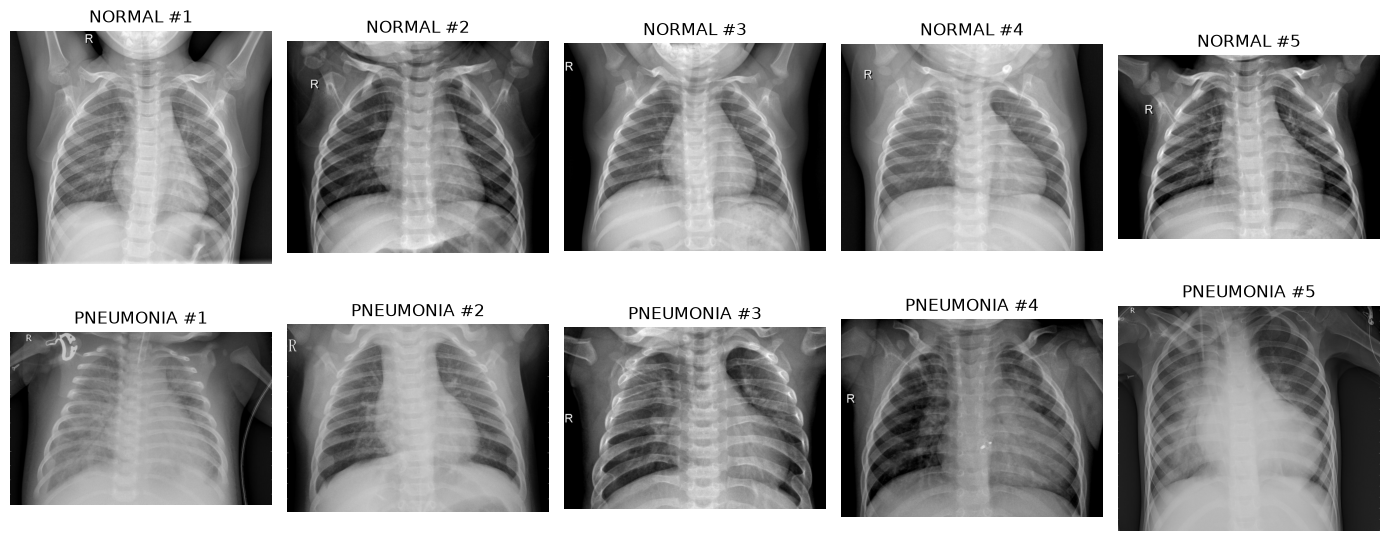

In [7]:
# TODO 1c: Display a 2x5 grid of sample images (5 NORMAL, 5 PNEUMONIA) so you can eyeball them.
# Hint: plt.subplots(2, 5, figsize=(14, 6)), then loop rows=classes, cols=files,
# using axes[row, col].imshow(...) and axes[row, col].axis("off").

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
# TODO: fill in the loop
classes = ["NORMAL", "PNEUMONIA"]

for row_idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_ROOT, "train", cls)
    files = os.listdir(cls_dir)[:5]  # Get the first 5 image filenames
    
    for col_idx, file_name in enumerate(files):
        img_path = os.path.join(cls_dir, file_name)
        
        # Open image using PIL
        with Image.open(img_path) as img:
            axes[row_idx, col_idx].imshow(img, cmap="gray")
            axes[row_idx, col_idx].set_title(f"{cls} #{col_idx + 1}")
            axes[row_idx, col_idx].axis("off")
            
plt.tight_layout()
plt.show()


In [8]:
# TODO 1d: Compute the class imbalance ratio in the TRAIN set (PNEUMONIA count / NORMAL count).
# You'll reuse this exact number's underlying counts again in Task 3 -- store them in variables.

train_normal_dir = os.path.join(DATA_ROOT, "train", "NORMAL")
train_pneumonia_dir = os.path.join(DATA_ROOT, "train", "PNEUMONIA")

n_normal = len(os.listdir(train_normal_dir)) if os.path.exists(train_normal_dir) else 0
n_pneumonia = len(os.listdir(train_pneumonia_dir)) if os.path.exists(train_pneumonia_dir) else 0
imbalance_ratio = n_pneumonia / n_normal if n_normal > 0 else 0

print(f"NORMAL:    {n_normal}")
print(f"PNEUMONIA: {n_pneumonia}")
print(f"Imbalance ratio (PNEUMONIA / NORMAL): {imbalance_ratio:.2f}x" if imbalance_ratio else "Fill in the TODOs above first")


NORMAL:    1341
PNEUMONIA: 3875
Imbalance ratio (PNEUMONIA / NORMAL): 2.89x


**Checkpoint — before moving on, answer for yourself:** roughly what's the
imbalance ratio you found, and are image sizes/modes actually consistent or
not? Both answers directly shape what you build next.

imbalance ratio is 3 
modes are consistent while sizes are not

## Task 2 — Build a Proper Train/Validation Split

**Concept — why we ignore the provided `val/` folder:** it only has 16
images. Any accuracy/loss number computed on 16 samples has huge variance —
getting one extra image right or wrong swings the metric by more than 6
percentage points. That's not reliable enough to base decisions on (like when
to stop training).

**Concept — stratified split:** a plain random split can accidentally skew
the class ratio between train and validation, especially with imbalance
already present. A *stratified* split preserves the same class ratio in both
subsets, so validation performance is actually representative.

**Concept — why `test/` stays untouched:** validation is used *during*
development (tuning, early stopping). The test set is only evaluated once, at
the very end, for an honest read on real-world performance. Don't peek at it
before then.


In [9]:
# TODO 2a: Build two parallel lists: all_paths (full file path to every train image)
# and all_labels (0 for NORMAL, 1 for PNEUMONIA), by walking both class folders in train/.
all_paths, all_labels = [], []
# TODO: fill this in with a loop over [("NORMAL", 0), ("PNEUMONIA", 1)]
for cls_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    cls_dir = os.path.join(DATA_ROOT, "train", cls_name)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(label)
            
print(f"Total train-folder images collected: {len(all_paths)}")


Total train-folder images collected: 5216


In [10]:
# TODO 2b: Use sklearn's train_test_split to create an 85/15 train/val split,
# STRATIFIED by class so the ratio is preserved in both.
# Hint: train_test_split(X, y, test_size=..., stratify=..., random_state=42)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    stratify=all_labels,
    random_state=42
)



if train_paths is not None:
    print(f"Train: {len(train_paths)} images | Val: {len(val_paths)} images")

    print(f"Train PNEUMONIA ratio: {train_labels.count(1)/len(train_labels):.3f}")
    print(f"Val PNEUMONIA ratio:   {val_labels.count(1)/len(val_labels):.3f}\n")
    # TODO: confirm these two ratios are close to each other -- that's stratification working


Train: 4433 images | Val: 783 images
Train PNEUMONIA ratio: 0.743
Val PNEUMONIA ratio:   0.743



## Task 3 — Preprocessing Pipeline

Five sub-steps, in this specific order (order matters — think about why
before moving to Task 4):

1. **Resize** every image to a fixed size — networks need constant-shape tensors to batch.
2. **Convert to one color mode** (grayscale) — X-rays carry no real color signal; dropping RGB triples cuts compute ~3x.
3. **Normalize to [0, 1]** — keeps gradients well-behaved during training.
4. **Augment training data only** — regularization via synthetic variety; augmenting val/test would corrupt your evaluation of real-world performance.
5. **Compute class weights from the *original* counts** (Task 1's numbers), *before* augmentation — augmentation doesn't change real-world class prevalence, so weighting must reflect the true distribution.


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 16

def load_and_preprocess(path, augment=False):
    """
    TODO 3a: Load the image at `path`, convert to grayscale, resize to (IMG_SIZE, IMG_SIZE),
    and scale pixel values to [0, 1] as a float32 numpy array.

    TODO 3b: If augment=True, apply (in any order):
      - a 50% chance random horizontal flip (np.fliplr)
      - a random rotation between -15 and +15 degrees
        (hint: convert back to a PIL Image, use .rotate(angle), then back to a normalized array)
      - a random brightness scaling factor between 0.9x and 1.1x (remember to np.clip to [0,1] after)

    Return the final array with an added channel dimension: shape (IMG_SIZE, IMG_SIZE, 1).
    """
    with Image.open(path) as img:
        img = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(img, dtype=np.float32) / 255.0

    if augment:
        if rng.random() < 0.5:
            arr = np.fliplr(arr)
        
        angle = rng.uniform(-15, 15)
        temp_img = Image.fromarray((arr * 255).astype(np.uint8))
        rotated = temp_img.rotate(angle)
        arr = np.array(rotated, dtype=np.float32) / 255.0
        
        factor = rng.uniform(0.9, 1.1)
        arr = np.clip(arr * factor, 0.0, 1.0)

    return np.expand_dims(arr, axis=-1)
    
    raise NotImplementedError("TODO: implement load_and_preprocess")


def generator_fn(paths, labels, augment):
    indices = np.arange(len(paths))
    if augment:
        rng.shuffle(indices)
    for idx in indices:
        img_arr = load_and_preprocess(paths[idx], augment=augment)
        yield img_arr, labels[idx]


def build_dataset(paths, labels, augment):
    """
    TODO 3c: Wrap load_and_preprocess in a tf.data.Dataset using Dataset.from_generator,
    with output_signature matching (IMG_SIZE, IMG_SIZE, 1) float32 images and scalar int32 labels.
    Shuffle only when augment=True. Batch with BATCH_SIZE and .prefetch(tf.data.AUTOTUNE).
    """
    output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    dataset = tf.data.Dataset.from_generator(
        lambda: generator_fn(paths, labels, augment),
        output_signature=output_signature
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    raise NotImplementedError("TODO: implement build_dataset")


train_ds = build_dataset(train_paths, train_labels, augment=True)
val_ds   = build_dataset(val_paths,   val_labels,   augment=False)
for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape, "value range:", float(tf.reduce_min(imgs)), "-", float(tf.reduce_max(imgs)))



Batch shape: (16, 96, 96, 1) value range: 0.0 - 1.0


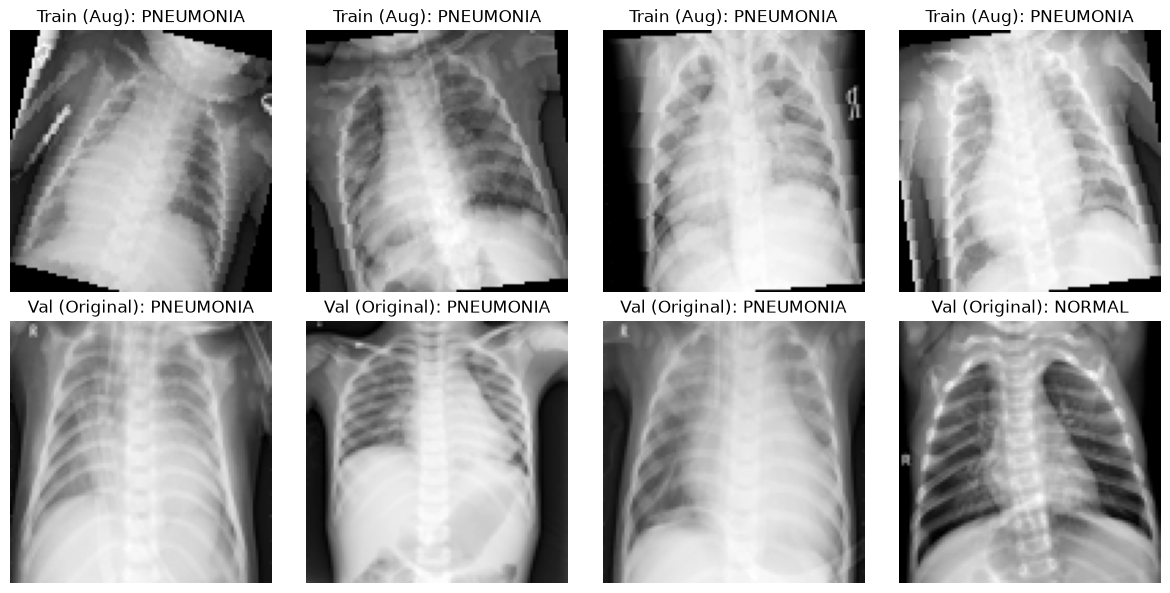

In [12]:
# TODO 3d: Visualize a few augmented training images next to their un-augmented val counterparts.
# This is a sanity check -- augmented images should look like plausible variations, not garbage.
# Hint: reuse the plt.subplots pattern from Task 1c, with train_ds.take(1) and val_ds.take(1).
# TODO 3d: Visualize augmented training images next to un-augmented validation images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Retrieve one batch from each dataset
for train_imgs, train_lbls in train_ds.take(1):
    for val_imgs, val_lbls in val_ds.take(1):
        for i in range(4):
            # Display Augmented Training Image
            axes[0, i].imshow(train_imgs[i].numpy().squeeze(), cmap="gray")
            lbl_str = "PNEUMONIA" if train_lbls[i].numpy() == 1 else "NORMAL"
            axes[0, i].set_title(f"Train (Aug): {lbl_str}")
            axes[0, i].axis("off")

            # Display Un-augmented Validation Image
            axes[1, i].imshow(val_imgs[i].numpy().squeeze(), cmap="gray")
            lbl_str = "PNEUMONIA" if val_lbls[i].numpy() == 1 else "NORMAL"
            axes[1, i].set_title(f"Val (Original): {lbl_str}")
            axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# TODO 3e: Compute class weights from the ORIGINAL train label counts (from Task 1/2),
# BEFORE any augmentation. Use sklearn's compute_class_weight with class_weight="balanced".
# Store the result as a dict: {0: weight_for_NORMAL, 1: weight_for_PNEUMONIA}

classes= np.unique(train_labels)
weights= compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y= train_labels
)


class_weight_dict = dict(
    zip(
        classes,
        weights
    )
)

if class_weight_dict:
    print("Class weights (NORMAL=0, PNEUMONIA=1):", class_weight_dict)

#     # TODO: think about and note down -- why compute this from the ORIGINAL counts,
#     # not from a count that includes augmented copies?


Class weights (NORMAL=0, PNEUMONIA=1): {np.int64(0): np.float64(1.9442982456140352), np.int64(1): np.float64(0.6730944427573641)}


## Task 4 — Build the CNN

**Concept recap for each layer type:**
- **Conv2D** — learns local spatial features (edges → textures → shapes across blocks).
- **BatchNorm** — normalizes activations for stabler, faster training.
- **ReLU** — the non-linearity; without it, stacked conv layers collapse into one linear function.
- **MaxPool** — downsamples feature maps, cuts compute, adds translation tolerance.
- **Dropout** — randomly zeroes neurons before the dense layers to fight overfitting on this small dataset.
- **Sigmoid output** — single neuron producing a (0,1) probability for binary classification.

Build from scratch (no pretrained weights) — this makes the benefit of
transfer learning in the Bonus section measurable rather than assumed.


In [14]:
# TODO 4: Build a Sequential CNN with:
#   - Input shape (IMG_SIZE, IMG_SIZE, 1)
#   - At least 3 blocks of: Conv2D -> BatchNormalization -> ReLU -> MaxPooling2D
#     (try filter counts like 32 -> 64 -> 128, increasing with depth)
#   - Flatten
#   - Dropout (around 0.5) BEFORE the dense layers
#   - A Dense(128, activation="relu") hidden layer
#   - A final Dense(1, activation="sigmoid") output layer
#
# Then compile with optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]


model = models.Sequential([
    layers.Input(shape=(IMG_SIZE,IMG_SIZE,1)),
    
    layers.Conv2D(32,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(2,2),

    layers.Conv2D(64,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(2,2),

    layers.Conv2D(128,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])


if model is not None:
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 96, 96, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 96, 96, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,453,121 (9.36 MB)

 Trainable params: 2,452,673 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 5 — Train With the Right Settings

- Pass `class_weight` (from Task 3e) into `model.fit()` so NORMAL mistakes count more during backprop.
- Add an `EarlyStopping` callback watching `val_loss`, with `patience` of 3–5 epochs and `restore_best_weights=True`.
- Train for up to 20–30 epochs and let early stopping decide the real cutoff — don't hand-pick a fixed epoch count.


In [15]:
# TODO 5a: Create an EarlyStopping callback (monitor="val_loss", patience 3-5, restore_best_weights=True).

early_stop= EarlyStopping(
    monitor= 'val_loss',
    patience= 5,
    restore_best_weights=True
)

# TODO 5b: Call model.fit(...) with train_ds, validation_data=val_ds, an epoch budget of ~20-30,
# class_weight=class_weight_dict, and callbacks=[early_stop]. Store the result in `history`.

history= model.fit (
    train_ds,
    validation_data= val_ds,
    epochs= 25,
    class_weight= class_weight_dict,
    callbacks= [early_stop]
)


Epoch 1/25


C:\Users\ISUG\anaconda3\envs\AI_Training_2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    277/Unknown 65s 230ms/step - accuracy: 0.8870 - loss: 0.4345

C:\Users\ISUG\anaconda3\envs\AI_Training_2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


278/278 ━━━━━━━━━━━━━━━━━━━━ 75s 264ms/step - accuracy: 0.8870 - loss: 0.4344 - val_accuracy: 0.7433 - val_loss: 0.9936
Epoch 2/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 48s 173ms/step - accuracy: 0.9411 - loss: 0.1574 - val_accuracy: 0.7854 - val_loss: 0.5079
Epoch 3/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 49s 174ms/step - accuracy: 0.9393 - loss: 0.1611 - val_accuracy: 0.8889 - val_loss: 0.3516
Epoch 4/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 49s 178ms/step - accuracy: 0.9459 - loss: 0.1391 - val_accuracy: 0.9527 - val_loss: 0.1181
Epoch 5/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 50s 180ms/step - accuracy: 0.9517 - loss: 0.1272 - val_accuracy: 0.9157 - val_loss: 0.2395
Epoch 6/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 187ms/step - accuracy: 0.9594 - loss: 0.1106 - val_accuracy: 0.9451 - val_loss: 0.1604
Epoch 7/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.9551 - loss: 0.1140 - val_accuracy: 0.9732 - val_loss: 0.0820
Epoch 8/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 186ms/step - accuracy: 0.9594 - loss: 0.1069 - val

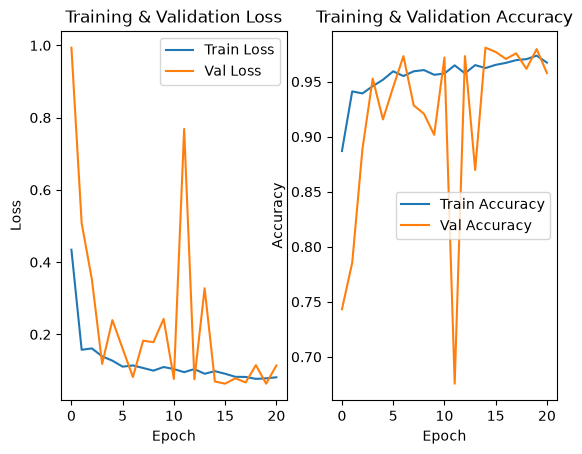

In [16]:
# TODO 5c: Plot training vs validation loss, and training vs validation accuracy,
# using history.history["loss"], history.history["val_loss"], etc. (two subplots side by side).

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


## Task 6 — Evaluate Properly

**Concept — why accuracy alone is misleading here:** imagine a trivial model
that always predicts PNEUMONIA. On an imbalanced test set that's majority
PNEUMONIA, that useless model still scores well above 50% accuracy despite
never correctly identifying a single NORMAL case. Per-class precision,
recall, and F1 expose that failure mode; overall accuracy hides it.


In [17]:
# TODO 6a: Build a test dataset the same way as val_ds (NO augmentation -- this is your
# untouched, final-answer evaluation set). Gather test_paths/test_labels, then build_dataset(...).

test_paths, test_labels = [], []
# TODO: fill in like Task 2a but for the "test" split

for cls_name,label in [("NORMAL",0),("PNEUMONIA",1)]:
    cls_dir= os.path.join(DATA_ROOT,'test',cls_name)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            test_paths.append(os.path.join(cls_dir,fname))
            test_labels.append(label)
            
test_ds= build_dataset(test_paths,test_labels,augment=False)



In [18]:
# TODO 6b: Get predictions on the test set. model.predict(test_ds) returns probabilities;
# threshold at 0.5 to get hard 0/1 predictions. Then print sklearn's classification_report
# with target_names=["NORMAL", "PNEUMONIA"].

y_true = np.array(test_labels)

y_true= np.array(test_labels)

y_prob= model.predict (test_ds)

y_pred= (y_prob > 0.5).astype(int).flatten()

print ("\n--- Classification Report ---")
print (classification_report(y_true,y_pred,target_names= ["NORMAL","PNEUMONIA"]))



39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.98      0.44      0.61       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.73       624
weighted avg       0.84      0.79      0.76       624



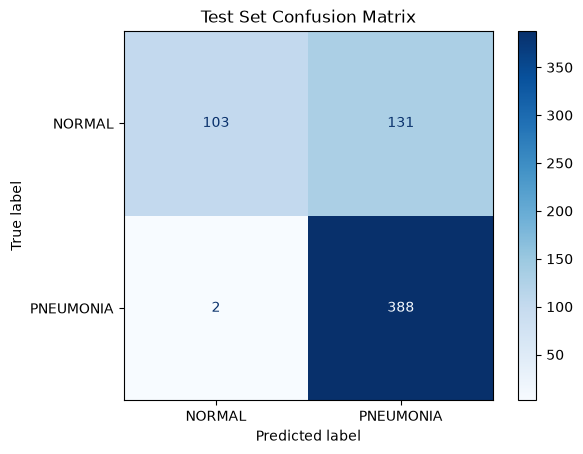

Recall on Normal class: 44.02%
False Negatives (PNEUMONIA -> NORMAL) 2
False positives (Normal -> PNEUMONIA) 131


In [22]:
# TODO 6c: Compute and plot the confusion matrix (ConfusionMatrixDisplay).
# Then answer explicitly, printed out:
#   - What is the recall on the NORMAL class specifically? 20%
#   - How many false negatives (real PNEUMONIA predicted as NORMAL) did the model make? 1
#   - How many false positives (real NORMAL predicted as PNEUMONIA)? 187
#   - In a medical context, which of those two error types is worse, and why?
#     (Write your answer as a comment or in the markdown cell below.)

cm= confusion_matrix(y_true,y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["NORMAL","PNEUMONIA"])

disp.plot(cmap=plt.cm.Blues)
plt.title ("Test Set Confusion Matrix")
plt.show()

tn,fp,fn,tp= cm.ravel()
recall_normal= tn/ (tn + fp) if (tn + fp) >0 else 0.0

print (f"Recall on Normal class: {recall_normal:.2%}")
print(f"False Negatives (PNEUMONIA -> NORMAL) {fn}")
print (f"False positives (Normal -> PNEUMONIA) {fp}")


**Your answer here (replace this text):** which error type is worse in this context, false negative or false positive, and why? \
> False negatives is much worse because we are saying that a person is normal while having pneumonia

## Bonus (optional, harder)

**Concept — ablation:** change exactly one variable (class weighting) while
holding everything else constant, so any difference in outcome can be
attributed specifically to that variable.


In [22]:
# TODO Bonus 1: Retrain an identical model architecture WITHOUT class_weight, and compare
# its confusion matrix / classification_report against your weighted model's.
# Hint: models.clone_model(model) gives you a fresh, untrained copy of the same architecture.



=== Bonus 1: Training Model WITHOUT Class Weights ===
Epoch 1/25


C:\Users\ISUG\anaconda3\envs\AI_Training_2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    277/Unknown 46s 161ms/step - accuracy: 0.9091 - loss: 0.3408

C:\Users\ISUG\anaconda3\envs\AI_Training_2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


278/278 ━━━━━━━━━━━━━━━━━━━━ 53s 186ms/step - accuracy: 0.9091 - loss: 0.3408 - val_accuracy: 0.7433 - val_loss: 1.6656
Epoch 2/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 182ms/step - accuracy: 0.9438 - loss: 0.1429 - val_accuracy: 0.9093 - val_loss: 0.2041
Epoch 3/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 188ms/step - accuracy: 0.9463 - loss: 0.1365 - val_accuracy: 0.9310 - val_loss: 0.1847
Epoch 4/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 186ms/step - accuracy: 0.9542 - loss: 0.1206 - val_accuracy: 0.9298 - val_loss: 0.2110
Epoch 5/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 50s 180ms/step - accuracy: 0.9623 - loss: 0.0987 - val_accuracy: 0.9668 - val_loss: 0.0715
Epoch 6/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 187ms/step - accuracy: 0.9626 - loss: 0.1018 - val_accuracy: 0.9183 - val_loss: 0.1990
Epoch 7/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 185ms/step - accuracy: 0.9601 - loss: 0.1050 - val_accuracy: 0.9642 - val_loss: 0.0990
Epoch 8/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 185ms/step - accuracy: 0.9598 - loss: 0.0988 - val

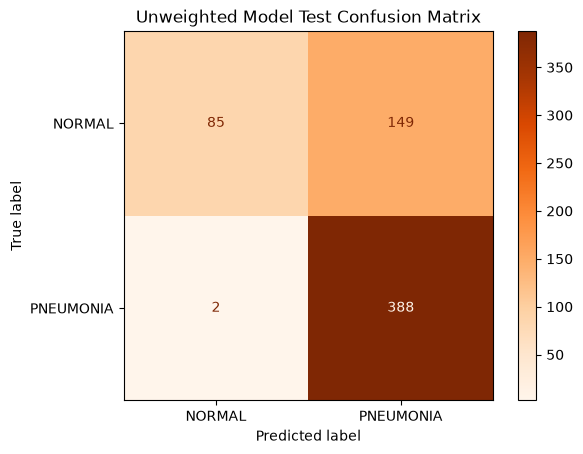

In [20]:
# ==========================================
# Bonus 1 — Retrain Without Class Weights
# ==========================================
print("\n=== Bonus 1: Training Model WITHOUT Class Weights ===")

# Create a fresh, untrained copy of the architecture
unweighted_model = models.clone_model(model)
unweighted_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Early stopping callback for unweighted model
early_stop_unweighted = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train without passing class_weight
history_unweighted = unweighted_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_unweighted]
)

# Evaluate on test set
y_prob_unweighted = unweighted_model.predict(test_ds)
y_pred_unweighted = (y_prob_unweighted > 0.5).astype(int).flatten()

print("\n--- Unweighted Model Classification Report ---")
print(classification_report(y_true, y_pred_unweighted, target_names=["NORMAL", "PNEUMONIA"]))

cm_unweighted = confusion_matrix(y_true, y_pred_unweighted)
disp_unweighted = ConfusionMatrixDisplay(confusion_matrix=cm_unweighted, display_labels=["NORMAL", "PNEUMONIA"])
disp_unweighted.plot(cmap=plt.cm.Oranges)
plt.title("Unweighted Model Test Confusion Matrix")
plt.show()

In [ ]:
# TODO Bonus 2 (harder): Swap in a pretrained MobileNetV2 base (frozen weights) with your
# own small classification head on top, and compare its performance and training time against
# your from-scratch CNN.
# Hint: tf.keras.applications.MobileNetV2(input_shape=..., include_top=False, weights="imagenet")
#       then set base_model.trainable = False before adding your own head.
# Note: MobileNetV2 expects 3-channel (RGB) input, and its own preprocessing normalization --
# check tf.keras.applications.mobilenet_v2.preprocess_input.



=== Bonus 2: Pretrained MobileNetV2 Classifier ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

...

Epoch 1/25


c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    277/Unknown 176s 605ms/step - accuracy: 0.8845 - loss: 0.2787

c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


278/278 ━━━━━━━━━━━━━━━━━━━━ 207s 714ms/step - accuracy: 0.8845 - loss: 0.2786 - val_accuracy: 0.9387 - val_loss: 0.1487
Epoch 2/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 195s 691ms/step - accuracy: 0.9168 - loss: 0.2118 - val_accuracy: 0.9527 - val_loss: 0.1374
Epoch 3/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 155s 558ms/step - accuracy: 0.9192 - loss: 0.1954 - val_accuracy: 0.9374 - val_loss: 0.1485
Epoch 4/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 140s 502ms/step - accuracy: 0.9201 - loss: 0.1973 - val_accuracy: 0.9285 - val_loss: 0.1704
Epoch 5/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 139s 501ms/step - accuracy: 0.9244 - loss: 0.1864 - val_accuracy: 0.8927 - val_loss: 0.2595
Epoch 6/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 140s 504ms/step - accuracy: 0.9276 - loss: 0.1817 - val_accuracy: 0.9042 - val_loss: 0.2318
Epoch 7/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 145s 523ms/step - accuracy: 0.9192 - loss: 0.1775 - val_accuracy: 0.9540 - val_loss: 0.1272
Epoch 8/25
278/278 ━━━━━━━━━━━━━━━━━━━━ 136s 489ms/step - accuracy: 0.9314 - loss: 0.17

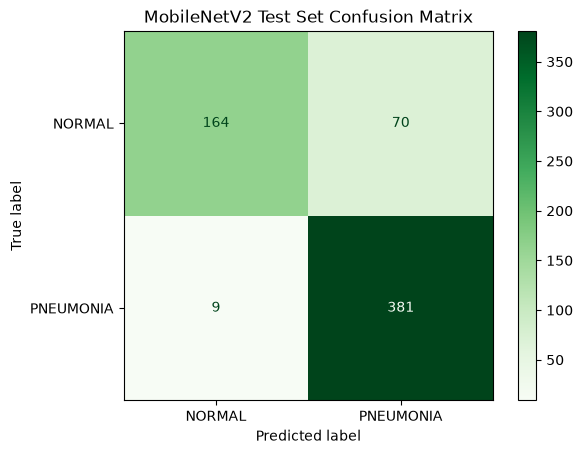

In [26]:
# ==========================================
# Bonus 2 — MobileNetV2 Transfer Learning
# ==========================================
print("\n=== Bonus 2: Pretrained MobileNetV2 Classifier ===")

# Preprocessing function tailored for MobileNetV2
def load_and_preprocess_mobilenet(path, augment=False):
    with Image.open(path) as img:
        # Convert to RGB (3-channels) as required by MobileNetV2
        img = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(img, dtype=np.float32)

    if augment:
        if rng.random() < 0.5:
            arr = np.fliplr(arr)
        
        angle = rng.uniform(-15, 15)
        temp_img = Image.fromarray(arr.astype(np.uint8))
        rotated = temp_img.rotate(angle)
        arr = np.array(rotated, dtype=np.float32)
        
        factor = rng.uniform(0.9, 1.1)
        arr = np.clip(arr * factor, 0.0, 255.0)

    # Use MobileNetV2's built-in scaling (scales pixels to [-1, 1])
    return tf.keras.applications.mobilenet_v2.preprocess_input(arr)

def generator_fn_mobilenet(paths, labels, augment):
    indices = np.arange(len(paths))
    if augment:
        rng.shuffle(indices)
    for idx in indices:
        img_arr = load_and_preprocess_mobilenet(paths[idx], augment=augment)
        yield img_arr, labels[idx]

def build_mobilenet_dataset(paths, labels, augment):
    output_signature = (
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    dataset = tf.data.Dataset.from_generator(
        lambda: generator_fn_mobilenet(paths, labels, augment),
        output_signature=output_signature
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build RGB datasets for MobileNetV2
train_ds_mb = build_mobilenet_dataset(train_paths, train_labels, augment=True)
val_ds_mb   = build_mobilenet_dataset(val_paths, val_labels, augment=False)
test_ds_mb  = build_mobilenet_dataset(test_paths, test_labels, augment=False)

# Load pretrained MobileNetV2 base with ImageNet weights (exclude top classifier)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model weights so they are not updated during training
base_model.trainable = False

# Build custom classification head on top
mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

mobilenet_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
mobilenet_model.summary()

# Train MobileNetV2 model
early_stop_mb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mb = mobilenet_model.fit(
    train_ds_mb,
    validation_data=val_ds_mb,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=[early_stop_mb]
)

# Evaluate MobileNetV2 on test set
y_prob_mb = mobilenet_model.predict(test_ds_mb)
y_pred_mb = (y_prob_mb > 0.5).astype(int).flatten()

print("\n--- MobileNetV2 Classification Report ---")
print(classification_report(y_true, y_pred_mb, target_names=["NORMAL", "PNEUMONIA"]))

cm_mb = confusion_matrix(y_true, y_pred_mb)
disp_mb = ConfusionMatrixDisplay(confusion_matrix=cm_mb, display_labels=["NORMAL", "PNEUMONIA"])
disp_mb.plot(cmap=plt.cm.Greens)
plt.title("MobileNetV2 Test Set Confusion Matrix")
plt.show()

## Writeup

Fill in with your own results once you've run this end-to-end on the real dataset:

1. Your final test-set precision/recall/F1 **per class** (not just overall accuracy):
2. Whether class weighting changed your confusion matrix meaningfully — with actual before/after numbers:
3. One thing that surprised you about the preprocessing step:

1. normal: precision(0.97) recall (0.39) f1 (0.56)
   pneumonia: precision 0.73 recall (0.99) f1(0.84)
   accuracy -> 0.77
2. > without class weight false negatives was 3, but after class weight applied it turns to 1. \  
    (because false negative is important it has to be minimized)
3. resizing and converting color formating